## SDK migration

`bigdata-client` and `bigdata-research-tools` are removed. Use REST (`BIGDATA_API_KEY`) / `bigdata-smart-batching` / OpenAI. Pass company CSVs (`RP_ENTITY_ID`, `COMPANY_NAME`) instead of watchlists. See [Thematic_Screener_CLI](../Thematic_Screener_CLI/) and [MIGRATION_PATTERNS.md](../MIGRATION_PATTERNS.md).


# Daily Digest for the Crude Oil Market


## Why It Matters
In commodity markets like crude oil, timely awareness of trending news can directly influence trading strategies, hedging decisions, and market forecasts. As news cycles accelerate, being able to identify not just what is being talked about but also its potential market impact is essential for staying ahead of price-moving developments.

## What It Does
This workflow identifies, verifies, clusters, and summarizes the most relevant and impactful news trends in the crude oil market using the Bigdata API for retrieval and large language models for topic analysis. It produces both daily market reports and structured datasets that can be used for monitoring or backtesting.

## How It Works
The notebook implements a four-step agentic workflow built on Bigdata API:

- **Lexicon Generation** of industry-specific jargon to maximize recall in news retrieval.

- **Content Retrieval** via the Bigdata API, splitting searches into daily windows and parallelizing keyword lookups for speed.

- **Topic Clustering & Selection** to verify, group, and summarize news into ranked trending topics, scoring each for trendiness, novelty, impact, and magnitude.

- **Custom Report Generation** in the form of a daily digest with a configurable ranking system, supported by granular news sources for verification.

## A Real-World Use Case 
This cookbook illustrates the full workflow through a practical example: tracking daily stories in the crude oil market during the Israel-Iran tensions of June 2025. You'll learn how to transform unstructured news into structured, ranked insights on market-moving narratives.


## Setup and Imports

## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import nest_asyncio
# NOTE: nest_asyncio.apply() is intentionally NOT called here. It patches the
# event loop in a way that breaks sniffio's async-library detection used by
# openai's AsyncOpenAI client (every async call fails with
# "unknown async library, or not in async context"). This notebook uses
# top-level `await` on the real async functions directly instead of the
# retired sync asyncio.run() wrappers, so nested event-loop support isn't needed.


In [2]:
import datetime
start = datetime.datetime.now()

## Environment Setup

The following cell configures the necessary path for the analysis

In [3]:
import os
import sys


current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Load Credentials

In [4]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
load_dotenv(script_dir / '.env')

BIGDATA_API_KEY = os.getenv('BIGDATA_API_KEY')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_API_KEY, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Import Required Libraries

Import the core libraries needed for trending topics analysis, including the lexicon generation classes and data processing tools.

In [5]:
import sys

sys.path.insert(0, ".")

from src.lexicon_generator import LexiconGenerator
from src.search_topics import search_by_keywords
from src.topics_extractor import (
    phase1_extract_topics,
    phase2_flatten_topics,
    phase3_consolidate_topics,
    phase4_summarize_topics,
    phase5_generate_titles,
    phase6_postprocess,
    filter_irrelevant_news,
    add_advanced_novelty_scores_to_df,
    add_market_impact_to_df,
)
from src.report_generator import (
    generate_html_report,
    save_html_report,
    prepare_data_for_report,
)

print("✅ Imported REST-based helpers from src/ (bigdata-client / bigdata-research-tools removed)")


✅ Imported REST-based helpers from src/ (bigdata-client / bigdata-research-tools removed)


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [6]:
# REST migration: there is no persistent SDK "Bigdata" client object anymore.
# src.bigdata_rest.BigdataRestClient (used internally by search_by_keywords) reads
# BIGDATA_API_KEY from the environment and sends it as the X-API-KEY header.
print("✅ Using Bigdata REST API (X-API-KEY header) — no SDK client object needed")


✅ Using Bigdata REST API (X-API-KEY header) — no SDK client object needed


## Defining Your Daily Digest Context and Parameters

To perform a trending topics analysis, we need to define a few key parameters:

- **Main Theme** (`main_theme`): The main topic, asset class, or context to analyze (e.g. Crude Oil)

- **Point of View** (`point_of_view`): The additional instructions to the LLM-based Impact and Magnitude generation. Use this parameter to add your domain expertise and contextualize your own definition of **Financial Materiality**. 

- **Time Period** (`start_date` and `end_date`): The date range over which to run the search

- **Document Type** (`document_type`): Specify which documents to search over (transcripts, filings, news)

- **Model Selection** (`llm_model`): The AI model used for semantic analysis and topic classification

In [7]:
# ===== Context Definition =====
main_theme = 'Crude Oil'

point_of_view = "a crude oil trader, where price is influenced by supply-demand dynamics, geopolitical events, and market sentiment. \
As a trader, you focus on changes in production, inventories, and economic indicators from key markets."

# ===== Specify Time Range =====
# Cost-control smoke run: single-day window to minimize billed API/OpenAI usage.
start_query = '2026-08-13'
end_query = '2026-08-13'

# ===== Query Configuration =====
document_type = "news"  # was DocumentType.NEWS (SDK) -> REST document_type filter value

# ===== LLM Specification =====
llm_model = "gpt-5.6-luna"


## Define Output Paths

We define the output paths for our results.

In [8]:
# Define output file paths for our report
output_dir = "report"
os.makedirs(output_dir, exist_ok=True)

export_path = f"{output_dir}/daily_digest_{main_theme.lower().replace(' ', '_')}.csv"

## Instantiating the Lexicon Generator

In this step, we identify the specialized industry-specific jargon relevant to the crude oil market to ensure a high recall in the content retrieval.

In [9]:
# Cost control: fewer seeds than the original 5 -> fewer OpenAI calls for this smoke run
lexicongenerator = LexiconGenerator(openai_key=OPENAI_API_KEY, model="gpt-5.6-luna", seeds=[123, 456])


In [10]:
keywords = await lexicongenerator._generate(theme=main_theme)

## Content Retrieval from Bigdata Search API

In this section, we perform a keyword search on the news content with the Bigdata API to retrieve documents, splitting the search over daily timeframes and multi-threading the content search on the individual keywords for speed purpose. The user can define the time range below to generate daily reports between the start and end dates.

With the list of market-specific keywords parameters, you can leverage the Search functionalities in bigdata-research-tools, built with Bigdata API, to run search at scale against news documents. We need to define 2 more parameters for search:

- **Frequency** (`freq`): The frequency of the date ranges to search over. It should at least match the frequency of your daily digest. Supported values:
    - `Y`: Yearly intervals.
    - `M`: Monthly intervals.
    - `W`: Weekly intervals.
    - `D`: Daily intervals. Defaults to `D`.
- **Document Limit** (`document_limit`): The maximum number of documents to return per query to Bigdata API.

In [11]:
# ===== Query Configuration =====
document_limit = 5   # Maximum number of chunks to retrieve per query to Bigdata API (cost control)
frequency = 'D'  # Query frequency


In [12]:
# Cost control: 1-2 broad crude-oil queries on a single-day smoke window.
search_keywords = [main_theme]
if keywords:
    search_keywords.append(keywords[0])
search_keywords = list(dict.fromkeys(search_keywords))
print(f"Searching Bigdata for: {search_keywords}")

results, daily_keyword_count = search_by_keywords(
    keywords=search_keywords,
    start_date=start_query,
    end_date=end_query,
    scope=document_type,
    freq=frequency,
    document_limit=document_limit)

print(f"Retrieved {len(results)} unique documents")
results.head()


Searching Bigdata for: ['Crude Oil', 'crude oil prices']


Retrieved 56 unique documents


,timestamp,text,headline,source_name,url,keyword
0,2026-08-07 11:10:04,Brent crude traded at USD81.75 a barrel at mid...,LONDON MARKET MIDDAY: FTSE 100 boosted by meta...,Alliance News,,Crude Oil
1,2026-08-07 13:44:01,The geopolitical gridlock was intensified by r...,US Oil Update: Oil Retreats Toward 2nd Straigh...,MT Newswires - Global Energy,,Crude Oil
2,2026-08-07 04:00:17,"""It's a maelstrom of disruption to shipping an...",Refining crunch keeps fuel prices high as crud...,Financial Times,https://www.ft.com/content/e7585052-7fd6-419a-...,Crude Oil
3,2026-08-07 19:17:50,"The Saudi crown prince, Turkish president and ...",Update: US Equity Indexes Rise Amid Growing Ex...,MT Newswires,,Crude Oil
4,2026-08-07 10:04:08,"Brent crude, for October delivery, rose 3.8 pe...",Crude oil price rises again,La Jornada,https://www.jornada.com.mx/2026/08/07/mundo/02...,Crude Oil


## Topic Clustering and Summarization

In this step, we perform topic modelling using a large language model to verify and cluster the news. Then, the summarization ensures topic selection identifying the top trending news for crude oil, while deriving advanced analytics to quantify the trendiness (based on news volume), novelty (based on daily changes in summaries), impact and magnitude (based on the financial materiality on crude oil prices) of the trending topics.

Before performing the topic clustering, we apply a verification layer to remove the news that are not relative to the oil market

In [13]:
semaphore_size = 1000 # Maximum number of concurrent requests to Openai API

# Assuming unique_reports is your DataFrame
filtered_reports = await filter_irrelevant_news(results, llm_model, OPENAI_API_KEY, main_theme, semaphore_size)


Filtering News:   0%|          | 0/56 [00:00<?, ?it/s]

/Users/bakulkumarkakadiya/dev/github/cookbook-master/bigdata-cookbook/Daily_Digest_Crude_Oil/src/topics_extractor.py:1619: UserWarning: Error in fetch_relevance for model gpt-4o-mini: invalid syntax (<unknown>, line 1). Returning None (will be filtered out).
  warnings.warn(f"Error in fetch_relevance for model {model}: {str(e)}. Returning None (will be filtered out).")



📊 Filtering Summary:
   Total records: 56
   Relevant: 45
   Irrelevant: 0
   ⚠️  Errors (filtered out): 11
   💡 Tip: Check model name and API key if error count is high


In this cell, we leverage a LLM to perform topic modeling, identifying and clustering the key topics from the news reports.

In [14]:
# Phase 1: Extraction
all_results, trending_topics_df, unique_reports = await phase1_extract_topics(
    unique_reports=filtered_reports,
    start_query=start_query,
    end_query=end_query,
    main_theme=main_theme,
    model=llm_model,
    api_key=OPENAI_API_KEY,
    batches=3
)

# Phase 2: Flattening  
flattened_df, total_cited = phase2_flatten_topics(
    trending_topics_df=trending_topics_df,
    unique_reports=unique_reports
)

# Phase 3: Consolidation
flattened_consolidated, mapping, stats = await phase3_consolidate_topics(
    flattened_raw_topics_df=flattened_df,
    model=llm_model,
    api_key=OPENAI_API_KEY,
    main_theme=main_theme
)

# Phase 4: Summarization
flattened_with_summaries = await phase4_summarize_topics(
    flattened_df=flattened_consolidated,
    model=llm_model,
    api_key=OPENAI_API_KEY,
    main_theme=main_theme,
)

# Phase 5: Generate Titles
flattened_with_titles = await phase5_generate_titles(
    flattened_df=flattened_with_summaries,
    model=llm_model,
    api_key=OPENAI_API_KEY
)

# Phase 6: Postprocessing
final_df = await phase6_postprocess(
    flattened_df=flattened_with_titles,
    api_key=OPENAI_API_KEY,
    main_theme=main_theme,
    total_cited_for_summary=0,
    unique_reports=unique_reports
)


Extracting Topics for 2026-08-07:   0%|          | 0/3 [00:00<?, ?it/s]

Extracting Topics for 2026-08-08:   0%|          | 0/3 [00:00<?, ?it/s]

Extracting Topics for 2026-08-09:   0%|          | 0/3 [00:00<?, ?it/s]

Extracting Topics for 2026-08-10:   0%|          | 0/3 [00:00<?, ?it/s]

Extracting Topics for 2026-08-11:   0%|          | 0/3 [00:00<?, ?it/s]

...

Generating text summaries:  10%|█         | 7/68 [00:01<00:08,  7.06it/s]

Generating text summaries:  26%|██▋       | 18/68 [00:01<00:02, 20.41it/s]

Generating text summaries:  59%|█████▉    | 40/68 [00:01<00:00, 50.11it/s]

Generating text summaries:  82%|████████▏ | 56/68 [00:01<00:00, 69.28it/s]

Generating text summaries: 100%|██████████| 68/68 [00:02<00:00, 30.39it/s]

## Topic Scoring

**Trendiness and Novelty Scores**: We derive analytics related to the trendiness of the topic based on the news volume, and the novelty of the topic based on the changes in daily summaries, evaluating the uniqueness and freshness of each topic.

In [15]:
filtered_df = final_df[final_df['Volume_Score'] >= 2]
flattened_trending_topics_df = filtered_df.copy()
# Calculate trendiness and novelty scores, assessing the uniqueness and freshness of each topic
flattened_trending_topics_df = await add_advanced_novelty_scores_to_df(flattened_trending_topics_df, api_key = os.environ['OPENAI_API_KEY'], main_theme = main_theme)


Calculating Novelty Scores:   0%|          | 0/11 [00:00<?, ?it/s]

**Financial Materiality**: We derive analytics related to the impact (Positive, Negative) and magnitude (High, Medium, Low) of the topics, inferring their  market impact on crude oil prices. The inference is based on the price mechanisms involving supply and demand dynamics, geopolitical factors among others.

In [16]:
flattened_trending_topics_df = add_market_impact_to_df(flattened_trending_topics_df, api_key = os.environ['OPENAI_API_KEY'], main_theme = main_theme, point_of_view = point_of_view)

We display the results of topic modeling and summarization. The **Topic** column represents the themes inferred through topic clustering using a LLM, which groups the news articles based on their content and underlying themes. The **Summary** provides a synthesized overview of all news articles within the same topic, offering a high-level view of the key messages for each cluster. The **Topic** is then rephrased into a concise form based on the summary. The **Text_Summary** provides a detailed summary of each individualchunk, capturing its core message.

For verification purpose, this actionable timestamped dataframe contains the granular news clustered into relevant topics, and also the advanced analytics of trendiness, novelty, impact, and magnitude scores to be potentially used for backtesting.

In [17]:
flattened_trending_topics_df.to_csv(export_path, index=False)

## Generate a Custom Daily Digest

In this step, we rank the topics, allowing the user to customize the ranking system to reindex the news, based on their trendiness, novelty, and financial materiality on crude oil prices. We finally display a daily market update, supported by the corresponding granular news and sources for verification purpose.

The user selects the date for the report summarizing the top trending topics, and customizes the ranking system to prioritize the topics based on volume (trendiness and media attention), novelty (based on the emergence of new daily news), impact direction (positive or negative), and magnitude (financial materiality). The ranking system prioritizes the criteria in the order specified by the user, allowing for a tailored focus on the most relevant aspects of the data.

The order in which the criteria are listed in user_selected_ranking determines their priority for ranking the topics within the report. The first criterion in the list has the highest priority, followed by the second, and then the third. The user can customize the ranking by choosing to prioritize impact direction (positive or negative), novelty, magnitude, or volume, and has the flexibility to select 1, 2, or all 3 criteria based on their specific needs.

In [18]:
available_dates = sorted(flattened_trending_topics_df['Date'].unique())
print(f"Dates with trending topics in this run: {[str(d) for d in available_dates]}")
if available_dates:
    specific_date = str(available_dates[-1])
else:
    specific_date = start_query
print(f"specific_date = {specific_date}")

user_selected_ranking = ['novelty', 'volume', 'magnitude']  # User can modify this list to change the ranking order
#impact_filter = 'positive_impact' #User can use the impact_filter to filter out the report


specific_date = 2026-08-12


In [19]:
prepared_reports = prepare_data_for_report(flattened_trending_topics_df, user_selected_ranking, impact_filter = None, report_date = specific_date)

In [20]:
# Generate and display the HTML report for each date
for report in prepared_reports:
    html_content = generate_html_report(
        report['date'],
        report['day_in_review'],
        report['topics'],
        f'Daily {main_theme} market update'  # Pass the main theme to dynamically generate the title
    )
    save_html_report(html_content, report['date'], main_theme)
    print("")
    print("")
    print("")

Report saved to ./report/2026-08-12_Crude_Oil.html






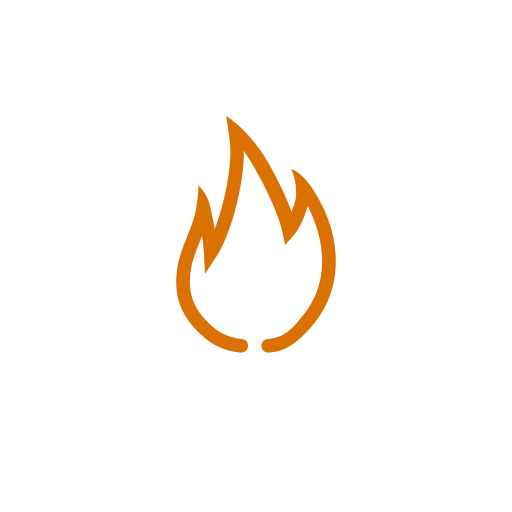
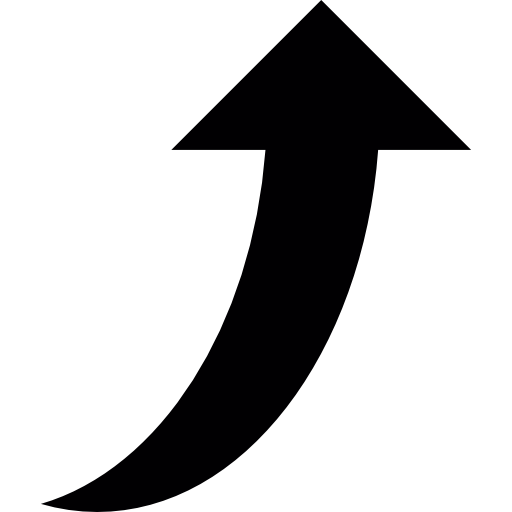
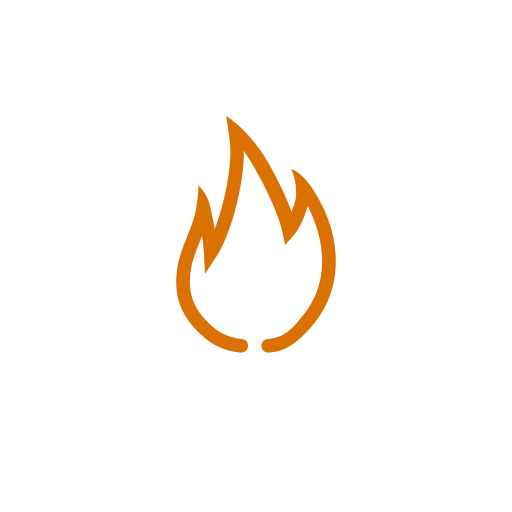
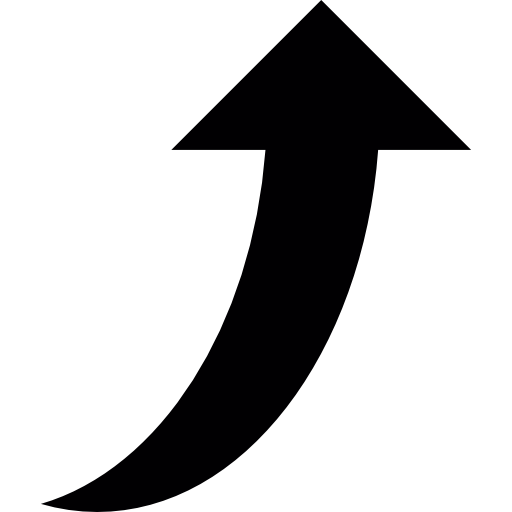
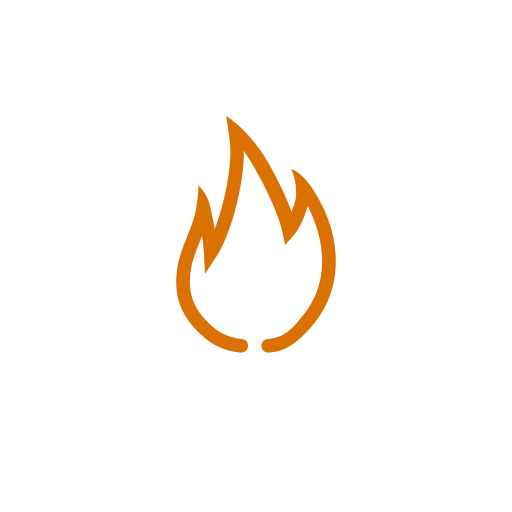
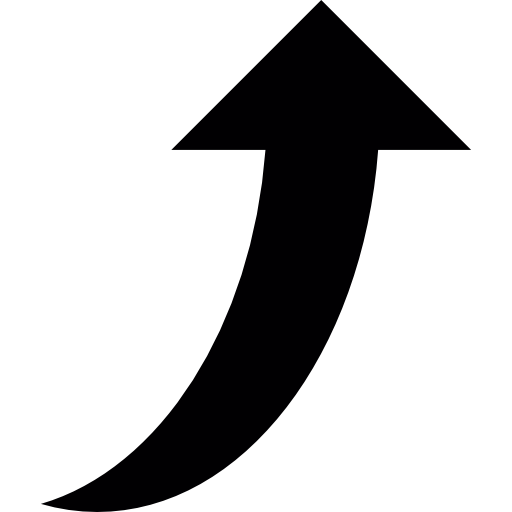

In [21]:
from IPython.display import HTML, display
display(HTML(html_content))